### NECO: Neural Collapse based Out Of Distribution Detection
#### Un semplice esempio su MNIST

In [1]:
from torchvision.datasets import MNIST, FashionMNIST
from torchvision import transforms
import torch.optim as optim
from torch import nn
import torch

import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Mean and std of MNIST
])

# Loading ID dataset
id_dataset = MNIST(root='./data', train=True, download=True, transform=transform)


In [3]:
transform_ood = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)) # Mean and std of FashionMNIST
])

# Loading OOD dataset
ood_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transform_ood)

In [4]:
from torch.utils.data import DataLoader

# DataLoader
id_loader = DataLoader(id_dataset, batch_size=256, shuffle=True)
ood_loader = DataLoader(ood_dataset, batch_size=256, shuffle=False)

In [5]:
# Shape evaluation
for idx, data in enumerate(ood_loader):
  x, y = data
  print(x.shape)
  print(y.shape)
  break


torch.Size([256, 1, 28, 28])
torch.Size([256])


In [6]:
# A simple CNN
class ConvNet(nn.Module):
  def __init__(self, output_dim):
    super().__init__()
    self.backbone = nn.Sequential(
        nn.Conv2d(1, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.Conv2d(128, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
    )
    self.fc = nn.Linear(64*2*2, 256)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.classifier = nn.Linear(256, output_dim, bias=False)

  def forward(self, x):
    x = self.backbone(x)
    x = self.flatten(x)
    x = self.fc(x) 
    features = self.relu(x) # output of penultimate linear layer
    x = self.classifier(features)
    return x, features


In [ ]:
import torch.nn.functional as F

def calculate_nc1(features, labels):
  N, D = features.shape
  num_classes = labels.max().item() + 1

  # global mean of id data
  mu_G = features.mean(dim=0, keepdim=True)

  mu_c_list = []

  # intra-class covariance
  sigma_w = torch.zeros((D, D), device=features.device)

  for c in range(num_classes):
      class_features = features[labels == c]
      if len(class_features) == 0:
          continue

      # class c mean
      m_c = class_features.mean(dim=0, keepdim=True)
      mu_c_list.append(m_c)

      diff = class_features - m_c
      sigma_w += diff.t() @ diff

  sigma_w /= N

  # between-class covariance
  mu_c_tensor = torch.cat(mu_c_list, dim=0)
  diff_b = mu_c_tensor - mu_G
  sigma_b = (diff_b.t() @ diff_b) / num_classes

  # NC1 score
  sigma_b_pinv = torch.linalg.pinv(sigma_b)
  nc1_matrix = sigma_w @ sigma_b_pinv
  nc1_value = torch.trace(nc1_matrix) / num_classes

  return nc1_value.item()


def evaluate_nc2(features, labels):
  unique_labels = torch.unique(labels)
  num_classes = len(unique_labels)

  # class mean
  mu_c = []
  for c in unique_labels:
      class_features = features[labels == c]
      mu_c.append(class_features.mean(dim=0))
  mu_c = torch.stack(mu_c) # [C, D]

  # global mean
  mu_G = mu_c.mean(dim=0)
  tilde_mu_c = mu_c - mu_G

  # Equinormality
  norms = torch.norm(tilde_mu_c, p=2, dim=1)
  en_std = torch.std(norms)
  en_mean = torch.mean(norms)
  equinormality_cv = en_std / en_mean

  # Equiangularity
  # Cosine similarity matrix between class means (after centering)
  tilde_mu_c_norm = F.normalize(tilde_mu_c, p=2, dim=1)
  cos_sim_matrix = torch.mm(tilde_mu_c_norm, tilde_mu_c_norm.t())

  # Extract only the values off the diagonal (the angles between different classes)
  mask = ~torch.eye(num_classes, dtype=bool)
  off_diag_cosines = cos_sim_matrix[mask]

  # The theoretical value is -1 / (C - 1)
  theoretical_cos = -1.0 / (num_classes - 1)

  # Measure the deviation from the theoretical value
  equiangularity_error = torch.mean(torch.abs(off_diag_cosines - theoretical_cos))

  return {
      "equinormality_cv": equinormality_cv.item(),
      "equiangularity_error": equiangularity_error.item(),
      "avg_cosine": off_diag_cosines.mean().item(),
      "theoretical_cosine": theoretical_cos
  }


def compute_orthodev(id_features, id_labels, ood_features):
  # global ood_mean
  mu_g_ood = torch.mean(ood_features, dim=0, keepdim=True)

  # class-mean of id-data
  classes = torch.unique(id_labels)
  mu_c_list = []
  for c in classes:
      class_features = id_features[id_labels == c]
      mu_c = torch.mean(class_features, dim=0, keepdim=True)
      mu_c_list.append(mu_c)

  mu_c_stack = torch.cat(mu_c_list, dim=0)

  # dot product and normalization
  cos_sim = F.cosine_similarity(mu_c_stack, mu_g_ood, dim=1) # [C]

  # orthodev score for ID/OOD orthogonality
  ortho_dev = torch.mean(torch.abs(cos_sim))

  return ortho_dev.item()


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ConvNet(output_dim=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
num_epochs = 200

model.to(device)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

# Initialization
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    if layer_in.bias is not None:
      layer_in.bias.data.fill_(0.0)

model.apply(weights_init)

nc1_per_epoch = []
nc2_per_epoch = []
nc5_per_epoch = []

model.train()

# Training pipeline
for epoch in range(num_epochs):
  running_loss = 0.0
  features_per_epoch = []
  labels_per_epoch = []

  for idx, (x, y) in enumerate(id_loader):
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    output, features = model(x)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    features_per_epoch.append(features.detach().cpu())
    labels_per_epoch.append(y.detach().cpu())

    if (idx + 1) % 100 == 0:
      print(f'Epoch [{epoch+1}/{num_epochs}], Step [{idx+1}/{len(id_loader)}], Loss: {loss.item():.4f}')

  scheduler.step()

  with torch.no_grad():
    ood_features = []
    for idx, (x, y) in enumerate(ood_loader):
      x, y = x.to(device), y.to(device)
      _, ood_feats = model(x)
      ood_features.append(ood_feats.detach().cpu())

    ood_features = torch.cat(ood_features, dim=0)

  features_per_epoch = torch.cat(features_per_epoch, dim=0)
  labels_per_epoch = torch.cat(labels_per_epoch, dim=0)

  nc1_per_epoch.append(calculate_nc1(features_per_epoch, labels_per_epoch))
  nc2_per_epoch.append(evaluate_nc2(features_per_epoch, labels_per_epoch))
  nc5_per_epoch.append(compute_orthodev(features_per_epoch, labels_per_epoch, ood_features))

  print(f'NC1: {nc1_per_epoch[-1]}')
  print(f'NC5: {nc5_per_epoch[-1]}')
  epoch_loss = running_loss / len(id_loader)
  print(f'--- Fine Epoca {epoch+1} | Loss Media: {epoch_loss:.4f} ---')

Epoch [1/200], Step [100/235], Loss: 0.0720
Epoch [1/200], Step [200/235], Loss: 0.0299
NC1: 0.33918577432632446
NC5: 0.7905933260917664
--- Fine Epoca 1 | Loss Media: 0.1567 ---
Epoch [2/200], Step [100/235], Loss: 0.0560
Epoch [2/200], Step [200/235], Loss: 0.0776
NC1: 0.21204698085784912
NC5: 0.7594529390335083
--- Fine Epoca 2 | Loss Media: 0.0463 ---
Epoch [3/200], Step [100/235], Loss: 0.0119
Epoch [3/200], Step [200/235], Loss: 0.0358
NC1: 0.18933692574501038
NC5: 0.7404296398162842
--- Fine Epoca 3 | Loss Media: 0.0296 ---
Epoch [4/200], Step [100/235], Loss: 0.0289
Epoch [4/200], Step [200/235], Loss: 0.0275
NC1: 0.18202939629554749
NC5: 0.741029679775238
--- Fine Epoca 4 | Loss Media: 0.0245 ---
Epoch [5/200], Step [100/235], Loss: 0.0534
Epoch [5/200], Step [200/235], Loss: 0.0293
NC1: 0.1733928620815277
NC5: 0.737013041973114
--- Fine Epoca 5 | Loss Media: 0.0191 ---
Epoch [6/200], Step [100/235], Loss: 0.0100
Epoch [6/200], Step [200/235], Loss: 0.0125
NC1: 0.1643328666687

In [9]:
# Saving metrics and model
np.save('saved_models/nc1.npy', nc1_per_epoch)
np.save('saved_models/nc2.npy', nc2_per_epoch)
np.save('saved_models/nc5.npy', nc5_per_epoch)
torch.save(model.state_dict(), 'saved_models/last_model.pth')

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Loading the trained model for evaluation
model = ConvNet(output_dim=10)
model.load_state_dict(torch.load('saved_models/neco_model.pth'))
model.to(device)

C:\Users\dario\AppData\Local\Temp\ipykernel_3576\2542869882.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('saved_models/neco_model.pth

ConvNet(
  (backbone): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (fc): Linear(in_features=256, out_features=256, bias=True)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Linear(in_features=256, out_features=10, bias=False)
)

In [10]:
from sklearn.metrics import accuracy_score

# Computation of final train accuracy
model.eval()

predictions = []
gts = []
features = []

for idx, (x, y) in enumerate(id_loader):
  x, y = x.to(device), y.to(device)
  output, feats = model(x)
  predicted = torch.argmax(output, dim=1)
  predictions.append(predicted.detach().cpu().numpy())
  gts.append(y.detach().cpu())
  features.append(feats.detach().cpu())

predictions = np.concatenate(predictions)
gts = np.concatenate(gts)

id_features = torch.cat(features, dim=0)
id_labels = torch.tensor(gts)

accuracy = accuracy_score(gts, predictions)

In [11]:
print(f'Final Train Accuracy: {accuracy:.4f}')

Final Train Accuracy: 0.9933


Controllo se le proprietà caratterizzanti Neural Collapse sono verificate.

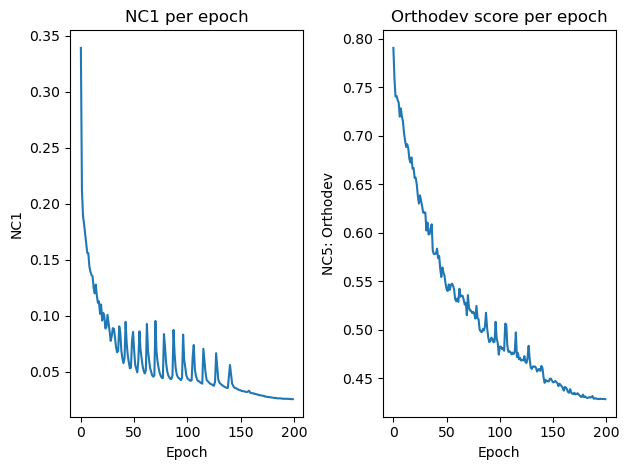

In [12]:
# NC1, NC5
fig, ax = plt.subplots(1,2)
ax[0].plot(list(range(num_epochs)), nc1_per_epoch)
ax[0].set_title('NC1 per epoch')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('NC1')

ax[1].plot(list(range(num_epochs)), nc5_per_epoch)
ax[1].set_title('Orthodev score per epoch')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('NC5: Orthodev')

plt.tight_layout()
plt.show()


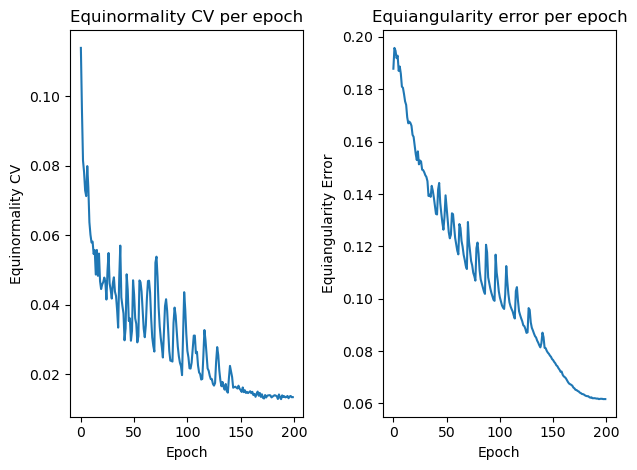

In [13]:
# NC2
fig, ax = plt.subplots(1, 2)
ax[0].plot(list(range(num_epochs)), [nc2['equinormality_cv'] for nc2 in nc2_per_epoch])
ax[0].set_title('Equinormality CV per epoch')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Equinormality CV')

ax[1].plot(list(range(num_epochs)), [nc2['equiangularity_error'] for nc2 in nc2_per_epoch])
ax[1].set_title('Equiangularity error per epoch')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Equiangularity Error')
plt.tight_layout()
plt.show()

In [14]:
# Extracting OOD features for final evaluation
model.eval()

ood_gts = []
ood_features = []

with torch.no_grad():
  for idx, (x, y) in enumerate(ood_loader):
    x, y = x.to(device), y.to(device)
    _, feats = model(x)
    ood_gts.append(y.detach().cpu())
    ood_features.append(feats.detach().cpu())

ood_gts = torch.cat(ood_gts, dim=0)
ood_features = torch.cat(ood_features, dim=0)

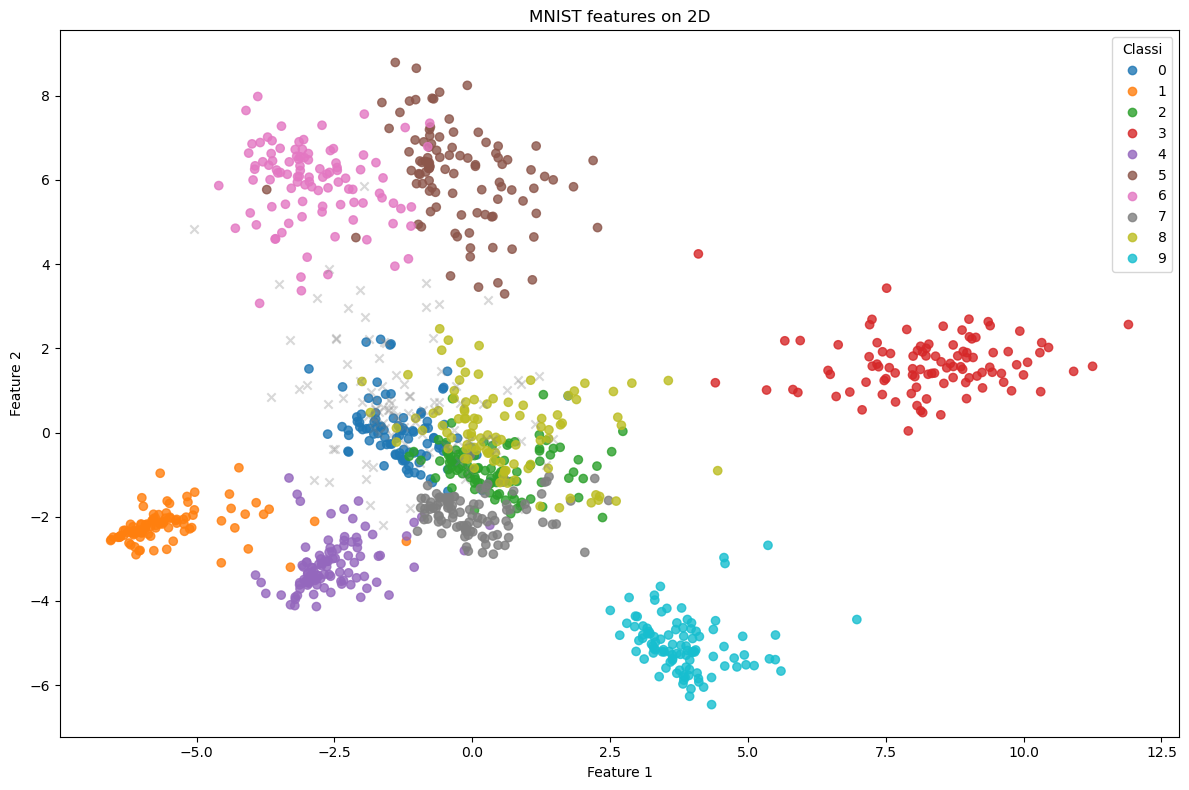

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_features_2d(id_features, labels, ood_features, examples_per_class=100, examples_ood=100, num_classes=10):
    """
    Plotta le features in 2D usando PCA, campiona 100 esempi per classe per una visualizzazione più chiara.
    """
    # Sampling ID data points per class
    indices_id = []
    for c in range(num_classes):
        idx = np.where(id_labels == c)[0]
        indices_id.append(np.random.choice(idx, examples_per_class, replace=False))
        
    sampled_indices = np.concatenate(indices_id)
    sampled_id_features = id_features[sampled_indices]
    sampled_labels = labels[sampled_indices]

    indices_ood = np.random.choice(ood_features.shape[0], examples_ood, replace=False)
    sampled_ood_features = ood_features[indices_ood]

    plt.figure(figsize=(12,8))
    scatter = plt.scatter(sampled_id_features[:, 0], sampled_id_features[:, 1], c=sampled_labels, cmap='tab10', alpha=0.8)
    plt.scatter(sampled_ood_features[:, 0], sampled_ood_features[:, 1], c='grey', alpha=0.3, label='OOD', marker='x')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title("MNIST features on 2D")
    plt.legend(*scatter.legend_elements(), title="Classi")
    plt.tight_layout()
    plt.show()

np.random.seed(42)  # for reproducibility
gts_plot = id_labels.numpy()
id_features_plot = id_features.numpy()
pca = PCA(n_components=2)
id_features_2d = pca.fit_transform(id_features_plot)
ood_features_2d = pca.transform(ood_features.numpy())
plot_features_2d(id_features_2d, gts_plot, ood_features_2d)

In [25]:
nc1_score = calculate_nc1(id_features, id_labels)
nc5_score = compute_orthodev(id_features, id_labels, ood_features)

print(f'NC1 score: {nc1_score}')
print(f'OrthoDev score (NC5): {nc5_score}')

NC1 score: 0.045612264424562454
OrthoDev score (NC5): 0.4507928490638733


In [26]:
from sklearn.decomposition import PCA

class NECODetector():
  def __init__(self, n_components=9, use_max_logit=False):
    self.n_components = n_components
    self.use_max_logit = use_max_logit
    self.pca = None
    self.is_fitted = False

  def fit(self, train_features):
    self.pca = PCA(self.n_components)
    self.pca.fit(train_features)

    self.is_fitted = True

    self.explained_variance_ratio_ = self.pca.explained_variance_ratio_
    self.cumulative_variance_ = np.cumsum(self.explained_variance_ratio_)

    # Statistics of explained variance
    var_at_n = self.cumulative_variance_[self.n_components - 1] * 100
    print(f"\n=== VARIANCE ANALYSIS ===")
    print(f"Features dimensionality: {train_features.shape[1]}")
    print(f"Using n_components: {self.n_components}")
    print(f"Variance explained by first {self.n_components} components: {var_at_n:.2f}%")
    return self

  def compute_score(self, test_features, logits=None):
    if not self.is_fitted:
        raise RuntimeError("Call .fit() before!")

    h_projected = self.pca.transform(test_features)

    norm_projected = np.linalg.norm(h_projected, ord=2, axis=1)
    norm_full = np.linalg.norm(test_features, ord=2, axis=1)

    neco_scores = norm_projected/ (norm_full + 1e-8)

    if self.use_max_logit and logits is not None:
        max_logits = np.max(logits, axis=1)
        neco_scores *= max_logits

    return neco_scores

In [27]:
from sklearn.metrics import roc_auc_score

def compute_auroc(id_scores, ood_scores):
    scores = np.concatenate([id_scores, ood_scores])
    
    # 1 for ID data, 0 for OOD data
    labels = np.concatenate([
        np.ones(len(id_scores)),   
        np.zeros(len(ood_scores))  
    ])
    
    # AUROC
    auroc = roc_auc_score(labels, scores)
    
    return auroc


In [28]:
for n_components in [4, 6, 8, 9, 10]:
    neco = NECODetector(n_components=n_components, use_max_logit=False)
    neco.fit(id_features)
    id_scores = neco.compute_score(id_features)
    ood_scores = neco.compute_score(ood_features)
    auroc = compute_auroc(id_scores, ood_scores)
    print(f"n_components: {n_components} | AUROC: {auroc:.4f} ({auroc*100:.2f}%)")


=== VARIANCE ANALYSIS ===
Features dimensionality: 256
Using n_components: 4
Variance explained by first 4 components: 62.09%
n_components: 4 | AUROC: 0.6719 (67.19%)

=== VARIANCE ANALYSIS ===
Features dimensionality: 256
Using n_components: 6
Variance explained by first 6 components: 81.29%
n_components: 6 | AUROC: 0.7609 (76.09%)

=== VARIANCE ANALYSIS ===
Features dimensionality: 256
Using n_components: 8
Variance explained by first 8 components: 96.14%
n_components: 8 | AUROC: 0.8198 (81.98%)

=== VARIANCE ANALYSIS ===
Features dimensionality: 256
Using n_components: 9
Variance explained by first 9 components: 99.63%
n_components: 9 | AUROC: 0.6953 (69.53%)

=== VARIANCE ANALYSIS ===
Features dimensionality: 256
Using n_components: 10
Variance explained by first 10 components: 99.89%
n_components: 10 | AUROC: 0.6619 (66.19%)



=== VARIANCE ANALYSIS ===
Features dimensionality: 256
Using n_components: 8
Variance explained by first 8 components: 96.14%

=== VARIANCE ANALYSIS ===
Features dimensionality: 256
Using n_components: 9
Variance explained by first 9 components: 99.63%


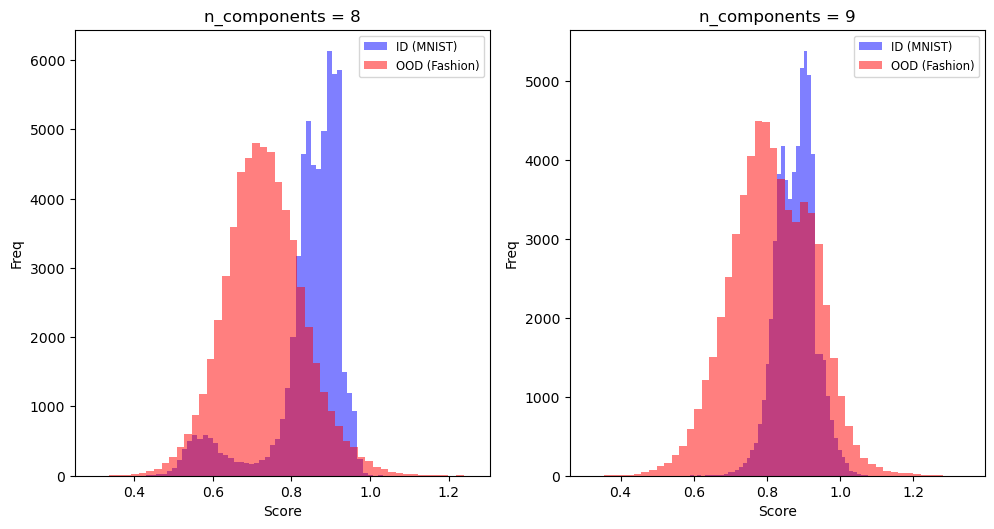

In [ ]:
# Definizione dei valori da testare
n_list = [8, 9]
n_plots = len(n_list)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten() # Appiattiamo la matrice di assi per iterare facilmente

for i, n in enumerate(n_list):
    neco = NECODetector(n_components=n, use_max_logit=False)
    neco.fit(id_features)
    
    id_scores = neco.compute_score(id_features)
    ood_scores = neco.compute_score(ood_features)
    
    ax = axes[i]
    ax.hist(id_scores, bins=50, alpha=0.5, label='ID (MNIST)', color='blue')
    ax.hist(ood_scores, bins=50, alpha=0.5, label='OOD (Fashion)', color='red')
    
    ax.set_title(f'n_components = {n}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Freq')
    ax.legend(fontsize='small')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() 
plt.show()


=== VARIANCE ANALYSIS ===
Features dimensionality: 256
Using n_components: 8
Variance explained by first 8 components: 96.14%


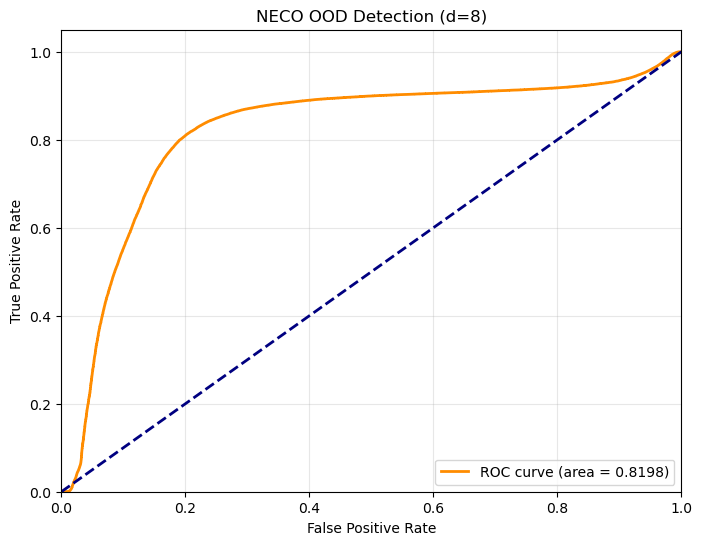

In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

neco = NECODetector(n_components=8, use_max_logit=False)
neco.fit(id_features)
id_scores = neco.compute_score(id_features)
ood_scores = neco.compute_score(ood_features)
# 1 for ID, 0 for OOD
y_true = [1] * len(id_scores) + [0] * len(ood_scores)
y_scores = np.concatenate([id_scores, ood_scores])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonale casuale
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'NECO OOD Detection (d={8})')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()